In [5]:
from langgraph.graph import StateGraph,START,MessagesState
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

In [6]:
load_dotenv()

True

In [7]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite"
)

In [15]:
def call_model(state:MessagesState):
    response=llm.invoke(state['messages'])
    return  {'messages':response}

In [16]:
builder=StateGraph(MessagesState)
builder.add_node("call_model",call_model)
builder.add_edge(START,"call_model")

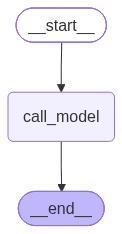

In [17]:
graph=builder.compile()
graph

In [ ]:
#graph.invoke({"messages":[{"role":"user","content":"hello,im jannat"}]})

{'messages': [HumanMessage(content='hello,im jannat', additional_kwargs={}, response_metadata={}, id='646b2f7a-2265-42e7-8fc5-51007fc61ab7')]}

In [ ]:
# in-memory saver se checkpoint bnaye gy
from langgraph.checkpoint.memory import InMemorySaver
checkpointer=InMemorySaver()
graph=builder.compile(checkpointer=checkpointer)
#compile lrty hue checkpointer provide kra ha 

In [20]:
config={"configurable":{"thread_id":"thread-1"}}

In [24]:
graph.invoke({"messages":[{"role":"user","content":"my name is jannat"}]},config)

{'messages': [HumanMessage(content='hello whats my name', additional_kwargs={}, response_metadata={}, id='58cb0ef5-3a4b-46fa-bade-b6906111a871'),
  AIMessage(content=[{'type': 'text', 'text': "Hello! I actually don't know your name yet. What would you like me to call you?", 'extras': {'signature': 'El4KXAERTTIP60q4TmMJARUBvUHdDaAOB9KnhVrCZsFnFmUyxERf8T1uhB0jl+qszOBaATTHZZL58EjjzGeR0znIUm7fJBDns1J8MSxhS1RDVGaHJz2XAMV/MFh4kKcU'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0728f-269f-7b61-9b81-5e57f431f502-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 21, 'total_tokens': 26, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='my name is jannat', additional_kwargs={}, response_metadata={}, id='370815d7-0988-4321-94e3-0627e07ca45a'),
  AIMessage(content=[{'type': 'text', 'text': 'Nice to meet y

In [27]:
graph.invoke({"messages":[{"role":"user","content":"whats my name"}]},config)

{'messages': [HumanMessage(content='hello whats my name', additional_kwargs={}, response_metadata={}, id='58cb0ef5-3a4b-46fa-bade-b6906111a871'),
  AIMessage(content=[{'type': 'text', 'text': "Hello! I actually don't know your name yet. What would you like me to call you?", 'extras': {'signature': 'El4KXAERTTIP60q4TmMJARUBvUHdDaAOB9KnhVrCZsFnFmUyxERf8T1uhB0jl+qszOBaATTHZZL58EjjzGeR0znIUm7fJBDns1J8MSxhS1RDVGaHJz2XAMV/MFh4kKcU'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0728f-269f-7b61-9b81-5e57f431f502-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 21, 'total_tokens': 26, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='my name is jannat', additional_kwargs={}, response_metadata={}, id='370815d7-0988-4321-94e3-0627e07ca45a'),
  AIMessage(content=[{'type': 'text', 'text': 'Nice to meet y

In [31]:
# snapshot le gy 
snap=graph.get_state(config)
vals=snap.values
for m in vals.get("messages",[]):
       print("-",type(m).__name__,":",m.content)

- HumanMessage : hello whats my name
- AIMessage : [{'type': 'text', 'text': "Hello! I actually don't know your name yet. What would you like me to call you?", 'extras': {'signature': 'El4KXAERTTIP60q4TmMJARUBvUHdDaAOB9KnhVrCZsFnFmUyxERf8T1uhB0jl+qszOBaATTHZZL58EjjzGeR0znIUm7fJBDns1J8MSxhS1RDVGaHJz2XAMV/MFh4kKcU'}}]
- HumanMessage : my name is jannat
- AIMessage : [{'type': 'text', 'text': 'Nice to meet you, Jannat! How can I help you today?', 'extras': {'signature': 'El4KXAERTTIPnRONwVV4Skt5BqUGHoMGTCLVUJrJTNGARNK60n8UMHFwxwwBjL1nQQ1M8IMxtrZ6WIyviRYoHkcs9PSwWM9jShcmNFMyr4lzoWFCU6HlokfbUc5qks0c'}}]
- HumanMessage : my name is jannat
- AIMessage : [{'type': 'text', 'text': "Got it, Jannat! I'll remember that. What's on your mind today?", 'extras': {'signature': 'El4KXAERTTIPLa+qmE49IOiapJ0Yb8zUy3wM+XN0iWRfG2azTqZ/N6NOfG7dBO3B5j/IxE2Ti5+o9fdKEJmWj347DOkxmTpE141rokIjNukpDjOWfeWo35rB6QcdB0NR'}}]
- HumanMessage : my name is jannat
- AIMessage : [{'type': 'text', 'text': "I know, Jannat! It'